In [3]:
import pandas as pd
import numpy as np

In [4]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI


d:\Data_analytics_new\Sub11_Agentic_AI_System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from typing import TypedDict, Annotated, List
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AIMessage
import requests
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

In [6]:
load_dotenv()

True

In [7]:
### Define the LLM

import os
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

llm = get_groq_llm()

In [26]:
class FinBot(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    off_topic: bool

In [27]:
class TopicModel(BaseModel):
    off_topic: bool = Field(..., description="Whether the query is off-topic")

In [28]:
structured_llm= llm.with_structured_output(TopicModel)

In [29]:
def offtopic_check(state: FinBot):

    query = state["messages"][-1].content

    response = structured_llm.invoke([
        SystemMessage(
            content="""
            Determine whether the query is finance related.

            Return:
            off_topic=True -> not finance related
            off_topic=False -> finance related
            """
        ),
        HumanMessage(content=query)
    ])

    return {
        "off_topic": response.off_topic
    }

In [30]:
def route_check(state: FinBot):
    if state["off_topic"]:
        return "offtopic"
    return "ontopic"

In [31]:
from langchain_core.messages import AIMessage

def offtopic(state: FinBot):
    return {
        "messages": [
            AIMessage(
                content="I can only answer finance-related questions."
            )
        ]
    }

In [32]:
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

In [33]:
# Make tool list
tools = [get_stock_price]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [34]:
def ontopic(state: FinBot):

    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }

In [35]:
tool_node = ToolNode(tools)  # Executes tool calls

In [36]:
graph = StateGraph(FinBot)
graph.add_node('offtopic_check', offtopic_check)
graph.add_node('offtopic', offtopic)
graph.add_node('ontopic', ontopic)
graph.add_node('tool_node', tool_node)

In [37]:
graph.add_edge(START, 'offtopic_check')
graph.add_conditional_edges('offtopic_check', route_check, {
    'offtopic': 'offtopic',
    'ontopic': 'ontopic'
})
graph.add_conditional_edges("ontopic", tools_condition,{
    "tools": "tool_node",
    "__end__": END
})
graph.add_edge('tool_node', 'ontopic')
graph.add_edge('offtopic', END)

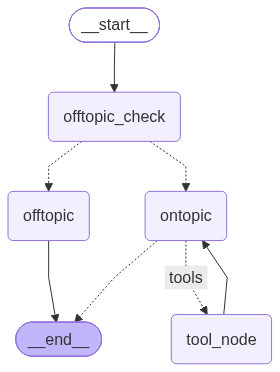

In [38]:
checkpoint = InMemorySaver()
chatbot = graph.compile(checkpointer=checkpoint)

chatbot

In [39]:
config = {"configurable": {"thread_id": "1"}}

In [42]:
config = {"configurable": {"thread_id": "2"}}

out = chatbot.invoke(
    {
        "messages": [
            HumanMessage(content="What is the stock price of AAPL?"),
        ]
    },
    config=config
)

for msg in out["messages"]:
    print(type(msg).__name__, ":", msg.content)

HumanMessage : What is the stock price of AAPL?
AIMessage : 
ToolMessage : {"Global Quote": {"01. symbol": "AAPL", "02. open": "310.7900", "03. high": "313.5900", "04. low": "308.2100", "05. price": "309.9000", "06. volume": "25869807", "07. latest trading day": "2026-08-25", "08. previous close": "310.3400", "09. change": "-0.4400", "10. change percent": "-0.1418%"}}
AIMessage : The latest price for **AAPL** is **$309.90** (as of 2026‑08‑25).


In [43]:
list(chatbot.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='What is the stock price of AAPL?', additional_kwargs={}, response_metadata={}, id='85e2f562-ae07-4f6b-8063-edb1b0a366b2'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 156, 'total_tokens': 194, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 13, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.475721021, 'prompt_time': 0.009677399, 'completion_time': 0.055985282, 'total_time': 0.065662681}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_334cc21c60', 'id': 'chatcmpl-f84b7b08-96ab-4e25-a428-d5f2b3e6a22d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a03e6f-494a-7202-a2a3-f0f5cf30d7c2-0', tool_calls=[{'name': 'get_stock_price', 'args': {'symbol': 'AAPL'}, 'id'